In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2, norm
from scipy.interpolate import interp1d
from scipy.special import factorial
from scipy.integrate import quad
import os
import sys
sys.path.append('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release')
from Astrid.effective_area import bin_edges_to_centers, bin_centers_to_edges, apply_energy_smearing
import nuSIprop

import ultranest
import h5py
import corner



energy_bins = np.logspace(4, 7, 3*20+1)
energy_centers = bin_edges_to_centers(energy_bins)
energy_bins_low_resolution = np.logspace(4, 7, 20+1)
energy_centers_low_resolution = bin_edges_to_centers(energy_bins_low_resolution)

livetime12 = 12*365*24*3600


hese12_events_df = pd.read_csv('4_to_7_HESE12/20bins/hese12_20bins_df.csv', index_col=0)

background_df = pd.read_csv('4_to_7_HESE12/20bins/background_20bins_df.csv', index_col=0)
background_df.rename(columns={'background': 'events'}, inplace=True)


effective_area_df = pd.read_csv('4_to_7_HESE12/60bins/effective_area_4_to_7.csv', index_col=0)

energy_edges_MESE = [1.0, 2.15, 4.64, 10.0, 21.5, 46.4, 100.0, 215.4, 464.2, 1000.0, 2154.4, 4641.6, 10000.0, 100000.0]
energy_centers_MESE = [1.47, 3.16, 6.81, 14.7, 31.6, 68.1, 146.8, 316.2, 681.3, 1467.8, 3162.3, 6812.9, 31622.8]
energy_edges_MESE = np.asarray(energy_edges_MESE)
energy_centers_MESE = np.asarray(energy_centers_MESE)
energy_edges_MESE *= 1e3 # GeV
energy_centers_MESE *= 1e3 # GeV

norm_segmented = [0.0, 5.4, 3.9, 4.41, 5.51, 3.34, 1.55, 0.31, 0.59, 0.327, 0.0, 0.25, 0.0]
sigma_upper = [5.2, 5.8, 2.1, 0.93, 0.72, 0.63, 0.50, 0.33, 0.42, 0.32, 0.19, 0.24, 0.76]
sigma_lower = [0.0, 5.4, 2.0, 0.90, 0.66, 0.52, 0.35, 0.31, 0.23, 0.187, 0.0, 0.16, 0.0]

# physical pivot used by the paper (100 TeV). Convert to GeV.
# observed y (E^2 phi) and asymmetric errors in the same units
E0 = 1e5    # if E in GeV; 100 TeV = 1e5 GeV
y_obs = np.asarray(norm_segmented) * 1e-18 * E0**2
sigma_upper = np.asarray(sigma_upper) * 1e-18 * E0**2
sigma_lower = np.asarray(sigma_lower) * 1e-18 * E0**2

sigma1 = 2 * sigma_upper * sigma_lower / (sigma_upper + sigma_lower)    # Acts as an 'average width'
sigma2 = (sigma_upper - sigma_lower) / (sigma_upper + sigma_lower)       # Encodes the asymmetry
print('sigma1: ', sigma1)
print('sigma2: ', sigma2)
"""
evolver = nuSIprop.pyprop(mphi = 50*1e6, # Mediator mass [eV]
			  g = 0.1, # Coupling
			  mntot = 0.1, # Sum of neutrino masses [eV]
			  si = 2.85, # Spectral index
			  norm = 1e-18, # Normalization of the free-streaming flux at 100 TeV [Default = 1]
			  majorana = True, # Majorana neutrinos? [Default = True]
			  non_resonant = True, # Include non s-channel contributions? Relevant for couplings g>~0.1 [Default = True]
			  normal_ordering = True, # Normal neutrino mass ordering? [Default = True]
			  N_bins_E = 300, # Number of energy bins, uniformly distributed in log space [Default = 300]
			  lEmin = 12, # log_10 (E_min/eV) [Default = 13]
			  lEmax = 17, # log_10 (E_max/eV) [Default = 17]
			  zmax = 5, # Largest redshift at which sources are included [Default = 5]
			  flav = 2, # Flavor of interacting neutrinos [0=e, 1=mu, 2=tau. Default = 2]
			  phiphi = True # Consider double-scalar production? If set to true, the files xsec/alpha_phiphi.bin and xsec/alphatilde_phiphi.bin must exist [Default = False]
                          )
evolver.evolve()
energies = evolver.get_energies()
bin_edges_high_resolution = bin_centers_to_edges(energies)
delta_E_nuSIprop = np.diff(bin_edges_high_resolution)    # Delta E in eV   """

sigma1:  [0.00000000e+00 5.59285714e-08 2.04878049e-08 9.14754098e-09
 6.88695652e-09 5.69739130e-09 4.11764706e-09 3.19687500e-09
 2.97230769e-09 2.36055227e-09 0.00000000e+00 1.92000000e-09
 0.00000000e+00]
sigma2:  [1.         0.03571429 0.02439024 0.01639344 0.04347826 0.09565217
 0.17647059 0.03125    0.29230769 0.26232742 1.         0.2
 1.        ]


'\nevolver = nuSIprop.pyprop(mphi = 50*1e6, # Mediator mass [eV]\n\t\t\t  g = 0.1, # Coupling\n\t\t\t  mntot = 0.1, # Sum of neutrino masses [eV]\n\t\t\t  si = 2.85, # Spectral index\n\t\t\t  norm = 1e-18, # Normalization of the free-streaming flux at 100 TeV [Default = 1]\n\t\t\t  majorana = True, # Majorana neutrinos? [Default = True]\n\t\t\t  non_resonant = True, # Include non s-channel contributions? Relevant for couplings g>~0.1 [Default = True]\n\t\t\t  normal_ordering = True, # Normal neutrino mass ordering? [Default = True]\n\t\t\t  N_bins_E = 300, # Number of energy bins, uniformly distributed in log space [Default = 300]\n\t\t\t  lEmin = 12, # log_10 (E_min/eV) [Default = 13]\n\t\t\t  lEmax = 17, # log_10 (E_max/eV) [Default = 17]\n\t\t\t  zmax = 5, # Largest redshift at which sources are included [Default = 5]\n\t\t\t  flav = 2, # Flavor of interacting neutrinos [0=e, 1=mu, 2=tau. Default = 2]\n\t\t\t  phiphi = True # Consider double-scalar production? If set to true, the fi

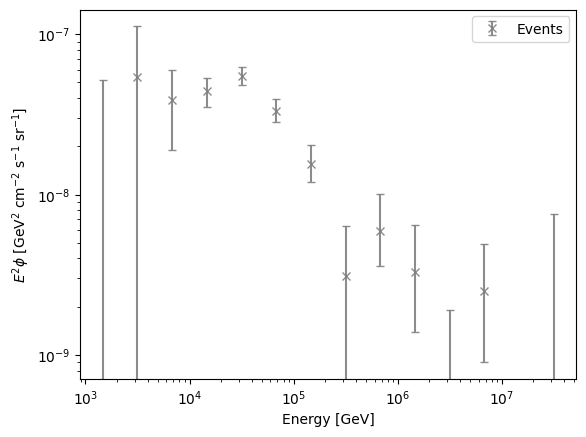

In [3]:
plt.errorbar(energy_centers_MESE, y_obs, 
             yerr=[sigma_lower, sigma_upper], 
             fmt='x', color='grey', label='Events', capsize=3, markersize=6, linestyle='none', alpha=0.9)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('$E^2 \phi$ [GeV$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.legend()

In [2]:
def total_events(flx, eff, livetime, norm, delta_E, save_to_csv=False):
    # Interpolate `flx` to the same energy bins as `eff`
    flx_interpolated = pd.DataFrame(
    {col: interp1d(flx.index, flx[col], bounds_error=False, fill_value="extrapolate")(eff.index)
     for col in flx.columns},
    index=eff.index)
    
    if eff['nu_e'].any() < 0:
        print('Negative effective area found')
    if eff['nu_mu'].any() < 0:
        print('Negative effective area found')
    if eff['nu_tau'].any() < 0:
        print('Negative effective area found')
    

    total_events_df = flx_interpolated * eff * livetime * norm 
    negative_mask = total_events_df < 0
    total_events_df[negative_mask] = 0
        
    #total_events_df = flx * eff_interpolated * livetime
    total_events_df['total_events'] = delta_E * (total_events_df['nu_e'] + total_events_df['nu_mu'] + total_events_df['nu_tau'])
    #total_events_df.index = eff.index 

    if save_to_csv==True:
        total_events_df.to_csv('total_events.csv')

    return total_events_df


# --- Prior transform: maps [0,1]^3 -> (Mphi, g, si) ---
def prior_transform(cube):
    u_Mphi, u_g, u_si, u_norm = cube

    # Mphi log-uniform in [0.1, 1000]
    Mphi_min, Mphi_max = 0.01, 100
    Mphi = Mphi_min * (Mphi_max / Mphi_min) ** u_Mphi
    #Mphi = 10**(Mphi_min + (Mphi_max - Mphi_min) * u_Mphi)

    # g log-uniform in [1e-4, 1]
    g_min, g_max = 1e-5, 1.0
    g = g_min * (g_max / g_min) ** u_g
    #g = 10**(g_min + (g_max - g_min) * u_g)

    # si uniform in [2.0, 3.0]
    si = 2.0 + (3.5 - 2.0) * u_si

    # norm log-uniform in [1e-19, 5e-17]
    norm_min, norm_max = 1e-19, 5e-17
    norm = norm_min * (norm_max / norm_min) ** u_norm

    #return np.stack([Mphi, g, si, norm], axis=1)
    return Mphi, g, si, norm

#return np.column_stack([Mphi, g, si])


def log_likelihood_poisson(data, predicted):
    # From Poisson distribution 
    return np.sum(-predicted + data*np.log(predicted) - np.log(factorial(data)))

def log_likelihood_gaussian(data, predicted, sigma):
    return np.sum(-0.5 * np.log(2 * np.pi) - np.log(sigma) - 0.5 * (data - predicted)**2 / sigma**2)


def log_likelihood_HESE(theta, evolver):

    Mphi, g, si = theta

    evolver.set_parameters(mphi=Mphi*1e6, g=g, si=si)
    evolver.evolve()
    flux = evolver.get_flux_fla()

    flx_df = pd.DataFrame(flux.T, index=energies, columns=['nu_e', 'nu_mu', 'nu_tau'])
    flx_df.index = flx_df.index / 1e9

    nuSIprop_df = total_events(flx=effective_area_df, eff=flx_df, livetime=livetime12, norm=1e-4, delta_E=delta_E)
    nuSIprop_smeared = apply_energy_smearing(energies=nuSIprop_df.index.values, events=nuSIprop_df['total_events'].values, resolution=0.1)
    nuSIprop_binned_events, _ = np.histogram(nuSIprop_df.index.values, weights=nuSIprop_smeared, bins=energy_bins_low_resolution)

    predicted = nuSIprop_binned_events + background_df['events'].values

    return log_likelihood_poisson(data=hese12_events_df['events'].values.astype(int), predicted=predicted)

"""# --- Likelihood wrapper ---
def loglike(theta):
    return log_likelihood(theta)  # your existing function"""


def SPL_flux(norm=2.13, si=2.548, energies=energy_centers_MESE):
    # SPL model flux
    # Normalized at E = 100TeV
    # Best fit MESE: norm = 2.13^{0.18}_{-0.17}, si = 2.548^{0.039}_{-0.041}
    
    return  norm * (energies / E0)**(-si)
    
    
def BPL_flux(norm=2.28, si1=1.72, si2=2.839, E_break=10**4.524, energies=energy_centers_MESE):
    # BPL model flux
    # Normalized at E = 100TeV = 1e5 GeV
    # Best fit MESE: norm = 2.28, si1 = 1.72, si2 = 2.839, E_break = 10**(4.524) GeV
    if E_break > 1e5:
        norm_break  = norm * (E_break / E0)**(-si1)
    else:
        norm_break  = norm * (E_break / E0)**(-si2)
    
    # If used for integration within the bin, energies will be a single value.
    if isinstance(energies, float):
        if energies < E_break:
            flux = norm_break * (energies / E0)**(-si1)
        else:
            flux = norm_break * (energies / E0)**(-si2)
    else:
        flux = np.zeros(len(energies))
        for i, E in enumerate(energies):
            if E < E_break:
                flux[i] = norm_break * (E / E_break)**(-si1)
            else:
                flux[i] = norm_break * (E / E_break)**(-si2)
    return flux 


def LP_flux(norm=2.58, alpha=2.669, beta=0.359, energies=energy_centers_MESE):
    # Log Parabola model flux
    # Normalized at E = 100TeV
    # Best fit MESE: norm = 2.42, alpha = 2.05, beta = 2.54
    return  norm * (energies / E0)**(-alpha - beta * np.log10(energies / E0)) 


def integrate_nuSIprop_E2phi(theta, evolver):
    Mphi, g, mntot, si, norm = theta
    #Mphi, g, si, norm = theta
    evolver.set_parameters(mphi=Mphi*1e6, g=g, mntot=mntot, si=si, norm=norm)
    evolver.evolve()
    flux = evolver.get_flux_fla()                      # shape (nE, flavors)
    E_samples = evolver.get_energies() / 1e9           # ensure same units as energy_edges_MESE (GeV)
    perflavor = (flux[0,:] + flux[1,:] + flux[2,:]) / 3.0  # or flux.T/columns depending on shape
    print('perflavor: ', perflavor)

    preds = []
    for Emin, Emax in zip(energy_edges_MESE[:-1], energy_edges_MESE[1:]):
        # select indices inside the bin (include endpoints carefully)
        mask = (E_samples >= Emin) & (E_samples <= Emax)
        Es = E_samples[mask]
        phis = perflavor[mask]

        if Es.size == 0:
            # fallback: interpolate phi on a fine grid and integrate, or use nearest neighbor
            preds.append(0.0)
            continue

        # integrate E^2 * phi(E) over the bin using trapezoid rule
        integrand = (Es**2) * phis
        integral = np.trapz(integrand, Es)   # approximates ∫ E^2 phi dE
        preds.append(integral / (Emax - Emin))   # bin-averaged E^2 phi

    return np.array(preds)



def integrate_model_E2phi(theta, bin_edges):
    #norm, si1, si2, E_break = theta
    y_bin_avg = []
    for i in range(len(bin_edges)-1):
        Emin, Emax = bin_edges[i], bin_edges[i+1]
        Es = np.logspace(np.log10(Emin), np.log10(Emax), 200)
        if len(theta) == 2:
            norm, si = theta
            vals = SPL_flux(norm, si, energies=Es) * Es**2
        elif len(theta) == 4:
            norm, si1, si2, E_break = theta
            vals = BPL_flux(norm, si1, si2, E_break, energies=Es) * Es**2
        elif len(theta) == 3:
            norm, alpha, beta = theta
            vals = LP_flux(norm, alpha, beta, energies=Es) * Es**2

        integral = np.trapz(vals, Es)
        avg = integral / (Emax - Emin)   # <-- critical
        y_bin_avg.append(avg)
    return np.array(y_bin_avg)

"""

def loglike_LP(theta):
    # log likelihood for LP model
    # theta = (norm, alpha, beta)
    norm, alpha, beta = theta
    y_pred = integrate_model_E2phi(theta, energy_edges_MESE)
    y_err = sigma1 + sigma2 * (y_pred - y_obs)
    ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2) #- np.sum(np.log(y_err))
    return ll


def loglike_BPL(theta):
    # log likelihood for BPL model
    # theta = (norm, si1, si2, E_break)
    norm, si1, si2, E_break = theta
    y_pred = model_predict_E2phi_per_bin(theta, BPL_flux, energy_edges_MESE)
    y_err = sigma1 + sigma2 * (y_pred - y_obs)
    ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2)
    return ll"""


def loglike_nuSIprop(theta):
    #Mphi, g, mntot, si, norm = theta
    Mphi, g, mntot, si, norm = theta
    y_pred = integrate_nuSIprop_E2phi(theta, interaction=True)
    y_err = sigma1 + sigma2 * (y_pred - y_obs)
    if np.any(y_err <= 0):
        print('Zeros in y_err for parameters: Mphi=', Mphi,', g=', g, ' mntot=', mntot, ' si=', si,', norm=', norm)
        print('y_err: ', y_err)
        print('y_pred: ', y_pred)
        y_err[y_err <= 0] = 1e-11
    ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2) #- np.sum(np.log(y_err))
    print('log likelihood nuSIprop: ', -0.5 * (y_obs - y_pred)**2 / y_err**2)
    return ll

"""def loglike(theta, interaction=True):
    # Valid for all flux models
    if interaction:
        y_pred = integrate_nuSIprop_E2phi(theta, interaction=True)
    else:
        y_pred = integrate_model_E2phi(theta, energy_edges_MESE)
    y_err = sigma1 + sigma2 * (y_pred - y_obs)
    print('y_err: ', y_err)
    if np.any(y_err <= 0):
        print('Zeros or negatives in y_err')
        y_err[y_err <= 0] = np.abs(y_err[y_err <= 0])
        obs = y_obs[y_err <= 0]
        pred = y_pred[y_err <= 0]
        y_obs[y_err <= 0] = pred
        y_pred[y_err <= 0] = obs
    ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2) #- np.sum(np.log(y_err))
    return ll"""
    
def loglike(theta):
    # Valid for all flux models
    y_pred = integrate_model_E2phi(theta, energy_edges_MESE)
    y_err = sigma1 + sigma2 * (y_pred - y_obs)
    #print('y_err: ', y_err)
    if np.any(y_err <= 0):
        print('Zeros or negatives in y_err')
        y_err[y_err <= 0] = np.abs(y_err[y_err <= 0])
        obs = y_obs[y_err <= 0]
        pred = y_pred[y_err <= 0]
        y_obs[y_err <= 0] = pred
        y_pred[y_err <= 0] = obs
        
    ll = -0.5 * np.sum((y_obs - y_pred)**2 / y_err**2) #- np.sum(np.log(y_err))
    return ll

Figure(760x760)


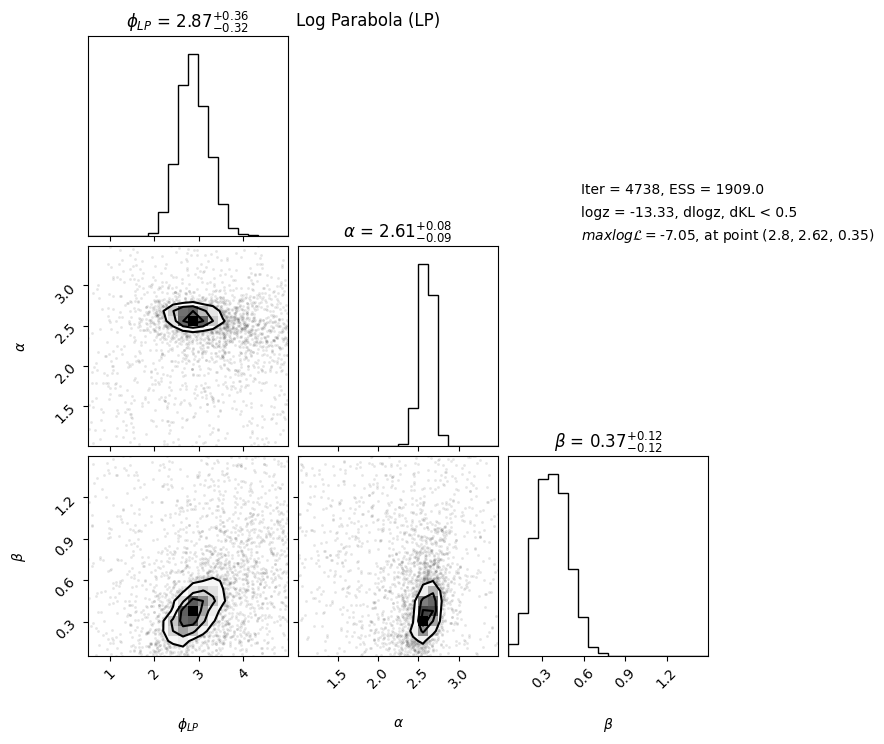

Figure(970x970)


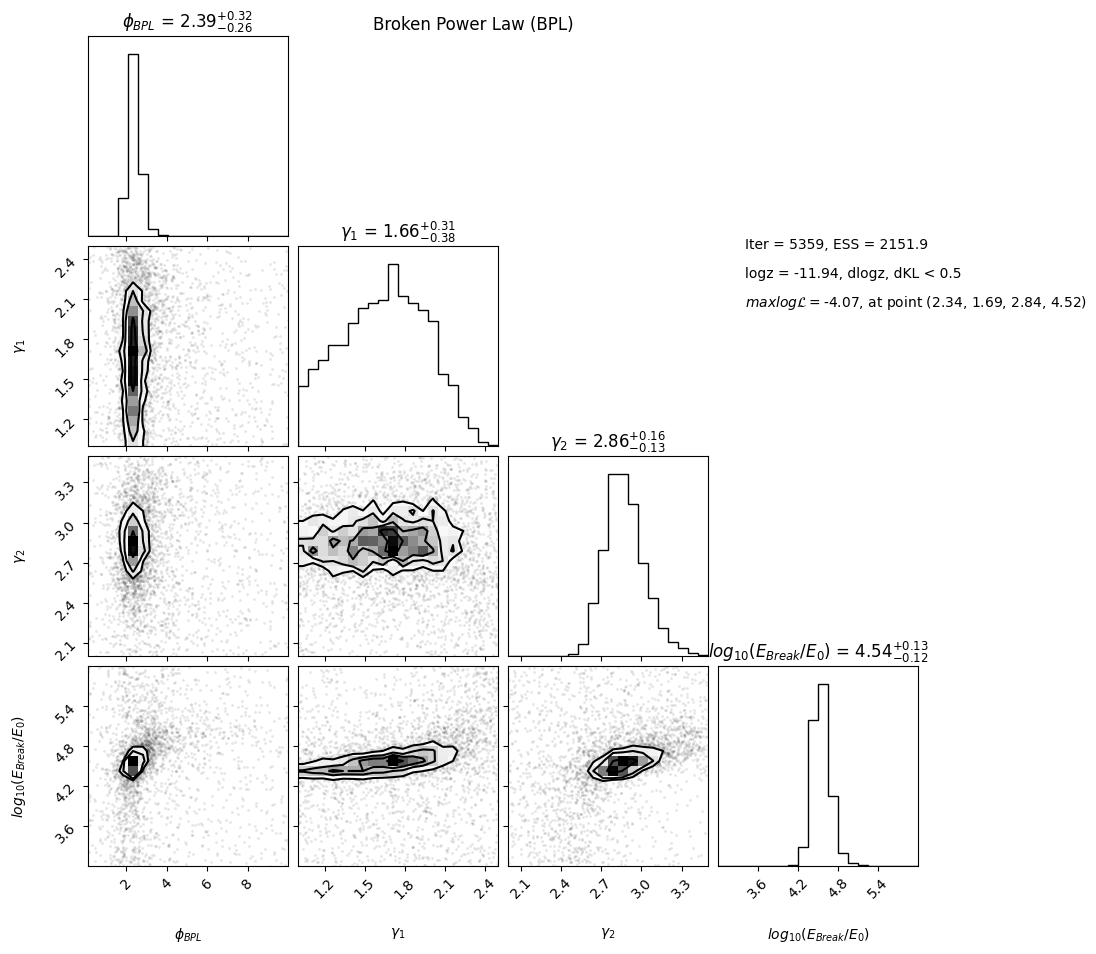

Figure(970x970)


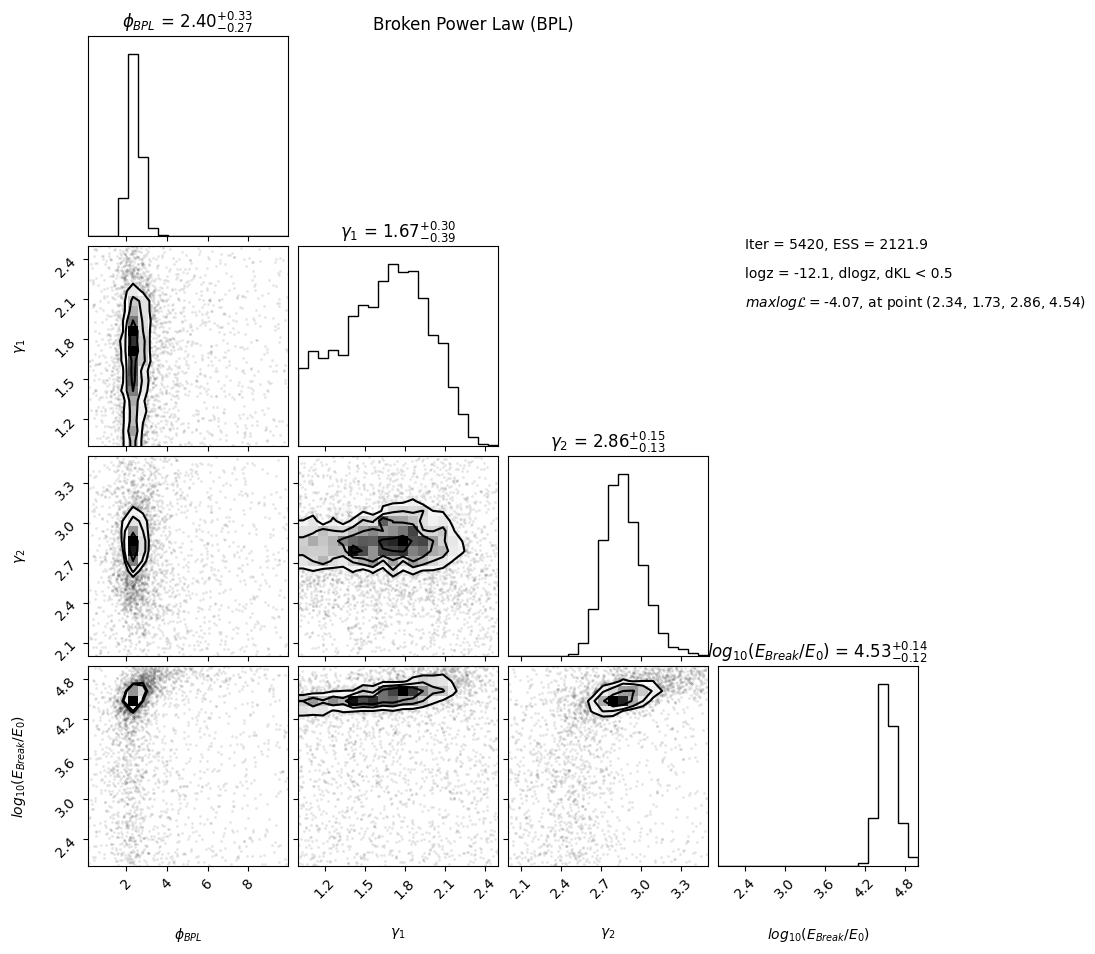

In [9]:
paramnames = ['norm', 'alpha', 'beta']
data_weighted = pd.read_csv('cluster/ultranest/mese/run6_LP/chains/weighted_post.txt', sep=" ")
weighted_post_samples = [data_weighted[param].values for param in paramnames]
weights = data_weighted['weight']

#dict = ultranest.read_file(log_dir='cluster/ultranest/mese/mntot_0065/run3/', x_dim=4)
# Read results directly from JSON file instead of using ultranest.read_file()
import json
with open('cluster/ultranest/mese/run6_LP/info/results.json', 'r') as f:
    results = json.load(f)


# Create a dict structure similar to what ultranest.read_file() would return
dict = [results, results]  # ultranest.read_file() typically returns [summary, results]
#dict = ultranest.read_file(log_dir='cluster/ultranest/mese/BPL/', x_dim=4)

fig = corner.corner(
    np.asarray(weighted_post_samples).T,
    labels=[r"$\phi_{LP}$", r"$\alpha$", r"$\beta$"],
    show_titles=True,
    title_fmt=".2f",
    axes_scale=['linear', 'linear', 'linear'],
    weights=weights,
    verbose=True
) 

print(fig)

niter = len(data_weighted)
ess = str(np.round(dict[1]['ess'], 1))
logz = str(np.round(dict[1]['logz'], 2))
max_logl = str(np.round(dict[1]['maximum_likelihood']['logl'], 2))
max_logl_point =  "(" + str(np.round(dict[1]['maximum_likelihood']['point'][0], 2)) + ", " + str(np.round(dict[1]['maximum_likelihood']['point'][1], 2)) + ", " + str(np.round(dict[1]['maximum_likelihood']['point'][2], 2)) + ")"
#max_logl_point = str(np.round(dict[1]['maximum_likelihood']['point'], 2))

fig.text(0.78, 0.74, "Iter = " + str(niter) + ", ESS = " + ess)
fig.text(0.78, 0.71, "logz = " + logz + ", dlogz, dKL < 0.5")
fig.text(0.78, 0.68, 
         r"$max log\mathcal{L} = $" + max_logl + ", at point " + max_logl_point)
fig.suptitle("Log Parabola (LP)")
plt.show()






paramnames = ['norm', 'si1', 'si2', 'E_break']
data_weighted = pd.read_csv('cluster/ultranest/mese/BPL/run2/chains/weighted_post.txt', sep=" ")
weighted_post_samples = [data_weighted[param].values for param in paramnames]
weights = data_weighted['weight']
# Transform E_break to log10 (assuming it's the 4th parameter, index 3)
weighted_post_samples[3] = np.log10(weighted_post_samples[3])


#dict = ultranest.read_file(log_dir='cluster/ultranest/mese/mntot_0065/run3/', x_dim=4)
# Read results directly from JSON file instead of using ultranest.read_file()
import json
with open('cluster/ultranest/mese/BPL/run2/info/results.json', 'r') as f:
    results = json.load(f)


# Create a dict structure similar to what ultranest.read_file() would return
dict = [results, results]  # ultranest.read_file() typically returns [summary, results]
#dict = ultranest.read_file(log_dir='cluster/ultranest/mese/BPL/', x_dim=4)

fig = corner.corner(
    np.asarray(weighted_post_samples).T,
    labels=[r"$\phi_{BPL}$", r"$\gamma_1$", r"$\gamma_2$", r"$log_{10}(E_{Break}/E_0)$"],
    show_titles=True,
    title_fmt=".2f",
    axes_scale=['linear', 'linear', 'linear', 'linear'],
    weights=weights,
    verbose=True
) 

print(fig)

niter = len(data_weighted)
ess = str(np.round(dict[1]['ess'], 1))
logz = str(np.round(dict[1]['logz'], 2))
max_logl = str(np.round(dict[1]['maximum_likelihood']['logl'], 2))
max_logl_point =  "(" + str(np.round(dict[1]['maximum_likelihood']['point'][0], 2)) + ", " + str(np.round(dict[1]['maximum_likelihood']['point'][1], 2)) + ", " + str(np.round(dict[1]['maximum_likelihood']['point'][2], 2)) + ", " + str(np.round(np.log10(dict[1]['maximum_likelihood']['point'][3]), 2)) + ")"
#max_logl_point = str(np.round(dict[1]['maximum_likelihood']['point'], 2))

fig.text(0.78, 0.74, "Iter = " + str(niter) + ", ESS = " + ess)
fig.text(0.78, 0.71, "logz = " + logz + ", dlogz, dKL < 0.5")
fig.text(0.78, 0.68, 
         r"$max log\mathcal{L} = $" + max_logl + ", at point " + max_logl_point)
fig.suptitle("Broken Power Law (BPL)")
plt.show()






data_weighted = pd.read_csv('cluster/ultranest/mese/BPL/run4/chains/weighted_post.txt', sep=" ")
weighted_post_samples = [data_weighted[param].values for param in paramnames]
weights = data_weighted['weight']
# Transform E_break to log10 (assuming it's the 4th parameter, index 3)
weighted_post_samples[3] = np.log10(weighted_post_samples[3])


#dict = ultranest.read_file(log_dir='cluster/ultranest/mese/mntot_0065/run3/', x_dim=4)
# Read results directly from JSON file instead of using ultranest.read_file()
import json
with open('cluster/ultranest/mese/BPL/run4/info/results.json', 'r') as f:
    results = json.load(f)


# Create a dict structure similar to what ultranest.read_file() would return
dict = [results, results]  # ultranest.read_file() typically returns [summary, results]
#dict = ultranest.read_file(log_dir='cluster/ultranest/mese/BPL/', x_dim=4)

fig = corner.corner(
    np.asarray(weighted_post_samples).T,
    labels=[r"$\phi_{BPL}$", r"$\gamma_1$", r"$\gamma_2$", r"$log_{10}(E_{Break}/E_0)$"],
    show_titles=True,
    title_fmt=".2f",
    axes_scale=['linear', 'linear', 'linear', 'linear'],
    weights=weights,
    verbose=True
) 

print(fig)

niter = len(data_weighted)
ess = str(np.round(dict[1]['ess'], 1))
logz = str(np.round(dict[1]['logz'], 2))
max_logl = str(np.round(dict[1]['maximum_likelihood']['logl'], 2))
max_logl_point =  "(" + str(np.round(dict[1]['maximum_likelihood']['point'][0], 2)) + ", " + str(np.round(dict[1]['maximum_likelihood']['point'][1], 2)) + ", " + str(np.round(dict[1]['maximum_likelihood']['point'][2], 2)) + ", " + str(np.round(np.log10(dict[1]['maximum_likelihood']['point'][3]), 2)) + ")"
#max_logl_point = str(np.round(dict[1]['maximum_likelihood']['point'], 2))

fig.text(0.78, 0.74, "Iter = " + str(niter) + ", ESS = " + ess)
fig.text(0.78, 0.71, "logz = " + logz + ", dlogz, dKL < 0.5")
fig.text(0.78, 0.68, 
         r"$max log\mathcal{L} = $" + max_logl + ", at point " + max_logl_point)
fig.suptitle("Broken Power Law (BPL)")
plt.show()


{'logl': -3.384212798687871, 'point': [0.44727279432446193, 0.015519735890792644, 2.6115632949445837, 10.20198720559154, 0.059045210101645366], 'point_untransformed': [0.33309441307558363, 0.5477210815799731, 0.40770886329638906, 0.48431511608376526, 0.0004968143037952649]}


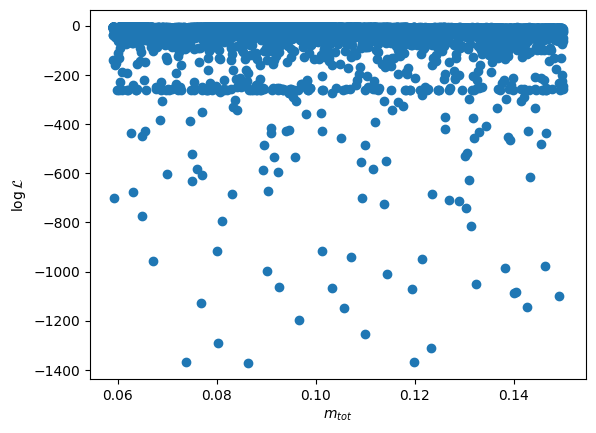

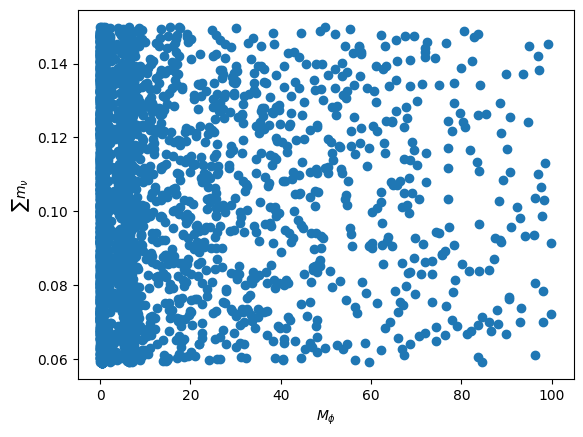

Figure(1180x1180)


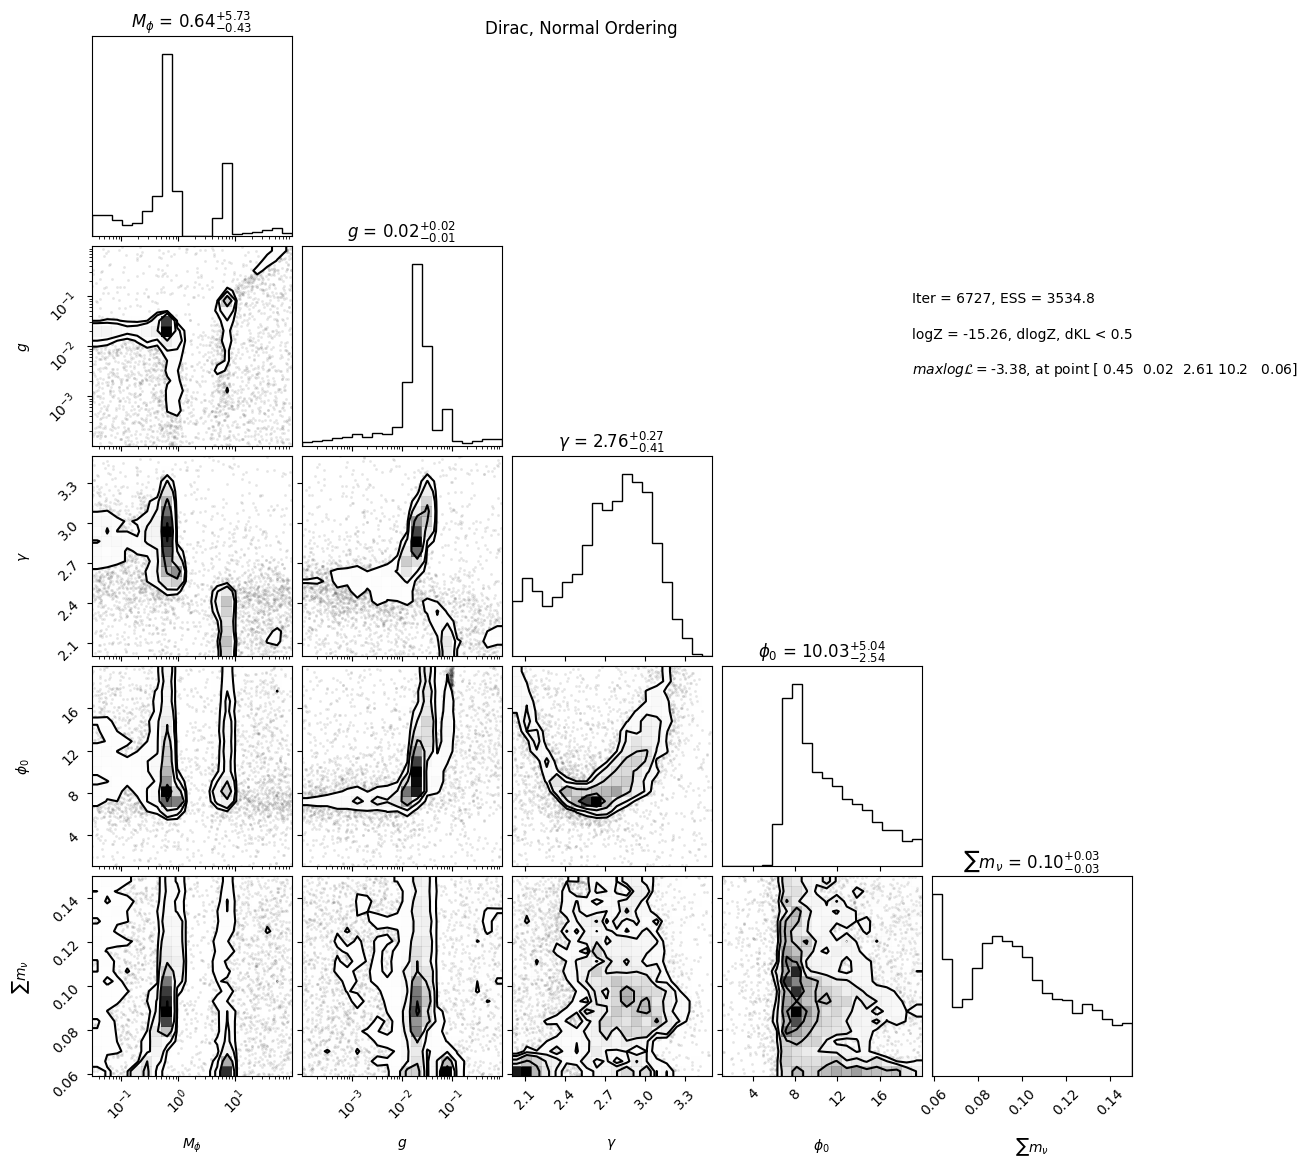

In [6]:
paramnames = ['Mphi', 'g', 'si', 'norm', 'mntot']
data_weighted = pd.read_csv('cluster/ultranest/mese/Dirac_NO/mntot_to_015/chains/weighted_post.txt', sep=" ")
weighted_post_samples = [data_weighted[param].values for param in paramnames]
weights = data_weighted['weight']
logl = data_weighted['logl']
mntot = data_weighted['mntot']
Mphi = data_weighted['Mphi']
g = data_weighted['g']
si = data_weighted['si']
norm = data_weighted['norm']

#dict = ultranest.read_file(log_dir='cluster/ultranest/mese/mntot_0065/run3/', x_dim=4)
# Read results directly from JSON file instead of using ultranest.read_file()
import json
with open('cluster/ultranest/mese/Dirac_NO/mntot_to_015/info/results.json', 'r') as f:
    results = json.load(f)

# Create a dict structure similar to what ultranest.read_file() would return
#dict = [results, results]  # ultranest.read_file() typically returns [summary, results]
maximum_likelihood = results['maximum_likelihood']
print(maximum_likelihood)


plt.scatter(mntot, logl)
plt.xlabel(r"$m_{tot}$")
plt.ylabel(r"$\log \mathcal{L}$")
plt.show()

plt.scatter(Mphi, mntot)
plt.xlabel(r"$M_\phi$")
plt.ylabel(r"$\sum m_\nu$")
plt.show()

#plt.scatter(g, mntot)
#plt.xlabel(r"$g$")


fig = corner.corner(
    np.asarray(weighted_post_samples).T,
    labels=[r"$M_\phi$", r"$g$", r"$\gamma$", r"$\phi_0$", r"$\sum m_\nu$"],
    show_titles=True,
    title_fmt=".2f",
    axes_scale=['log', 'log', 'linear', 'linear', 'linear'],
    weights=weights,
    verbose=True
) 

print(fig)
"""axes = np.array(fig.axes).reshape((5, 5)); print(axes)
ax = axes[1, 0]; 
ax.plot(Mphi, Mphi*SI, label="SI, ", color='r')
ax.plot(Mphi, Mphi*MI, label="MI, ", color='b')
ax.legend(loc='lower right')"""

niter = len(data_weighted)
ess = str(np.round(results['ess'], 1))
logz = str(np.round(results['logz'], 2))
max_logl = str(np.round(results['maximum_likelihood']['logl'], 2))
max_logl_point = str(np.round(results['maximum_likelihood']['point'], 2))

fig.text(0.78, 0.74, "Iter = " + str(niter) + ", ESS = " + ess)
fig.text(0.78, 0.71, "logZ = " + logz + ", dlogZ, dKL < 0.5")
fig.text(0.78, 0.68, 
         r"$max log\mathcal{L} = $" + max_logl + ", at point " + max_logl_point)
fig.suptitle('Dirac, Normal Ordering')
plt.show()


In [9]:



#loglike_spl = loglikeli(theta=[2.13*1e-18, 2.548])
#loglike_bpl = loglike(theta=[2.28*1e-18, 1.72, 2.839, 10**4.524], interaction=False) 


#theta = [2.698887410360228 * 1e-18, 2.6994688572999883, 0.4217432311439763]
#loglike_lp = loglike(theta, interaction=False)
#loglike_lp = loglike(theta=[2.58*1e-18, 2.668, 0.359], interaction=False)

# Best fit from ultanest sampling
theta_lp = [2.7982146210446617*1e-18, 2.6193949973483805, 0.35325301497805395]
theta_bpl = [2.3352447240802126*1e-18, 1.725344055352168, 2.8615770081540624, 34599.84488999645]
loglike_lp = loglike(theta_lp)
loglike_bpl = loglike(theta_bpl)

#print('loglike_spl: ', loglike_spl)
print('loglike_bpl: ', loglike_bpl)
print('loglike_lp: ', loglike_lp)

TS_BPL = 2 * (loglike_bpl - loglike_spl)
TS_LP = 2 * (loglike_lp - loglike_spl)
print('TS_BPL: ', TS_BPL)
print('TS_LP: ', TS_LP)





loglike_bpl:  -4.071313373744254
loglike_lp:  -7.914327292990947


NameError: name 'loglike_spl' is not defined

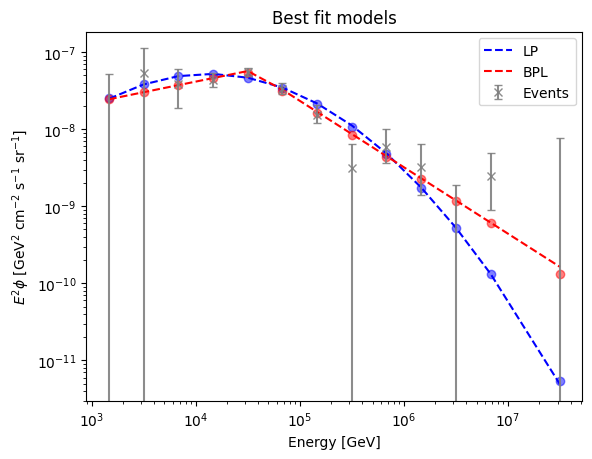

In [10]:
"""lp_flux = LP_flux(energies=energy_centers_MESE, alpha=2.668, beta=0.359, norm=2.58*1e-18)
LP_bin_avg = integrate_model_E2phi(theta=[2.58*1e-18, 2.668, 0.359], bin_edges=energy_edges_MESE)
print('LP_bin_avg: ', LP_bin_avg)
print('lp_flux raw: ', lp_flux * energy_centers_MESE**2)

bpl_flux = BPL_flux(energies=energy_centers_MESE, si1=1.72, si2=2.839, E_break=10**4.524, norm=2.28*1e-18)
BPL_bin_avg = integrate_model_E2phi(theta=[2.28*1e-18, 1.72, 2.839, 10**4.524], bin_edges=energy_edges_MESE)
print('BPL_bin_avg: ', BPL_bin_avg)
print('bpl_flux raw: ', bpl_flux * energy_centers_MESE**2)"""

lp_flux = LP_flux(energies=energy_centers_MESE, alpha=theta_lp[1], beta=theta_lp[2], norm=theta_lp[0])
lp_bin_avg = integrate_model_E2phi(theta=theta_lp, bin_edges=energy_edges_MESE)

bpl_flux = BPL_flux(energies=energy_centers_MESE, si1=theta_bpl[1], si2=theta_bpl[2], E_break=theta_bpl[3], norm=theta_bpl[0])
bpl_bin_avg = integrate_model_E2phi(theta=theta_bpl, bin_edges=energy_edges_MESE)

plt.scatter(energy_centers_MESE, lp_bin_avg, alpha=0.5, color='blue')
plt.plot(energy_centers_MESE, lp_flux * energy_centers_MESE**2, label='LP', color='blue', linestyle='--')
plt.scatter(energy_centers_MESE, bpl_bin_avg, alpha=0.5, color='red')
plt.plot(energy_centers_MESE, bpl_flux * energy_centers_MESE**2, label='BPL', color='red', linestyle='--')
plt.errorbar(energy_centers_MESE, y_obs, 
             yerr=[sigma_lower, sigma_upper], 
             fmt='x', color='grey', label='Events', capsize=3, markersize=6, linestyle='none', alpha=0.9)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('$E^2 \phi$ [GeV$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.legend()
plt.title('Best fit models')
plt.show()


In [8]:
import gc

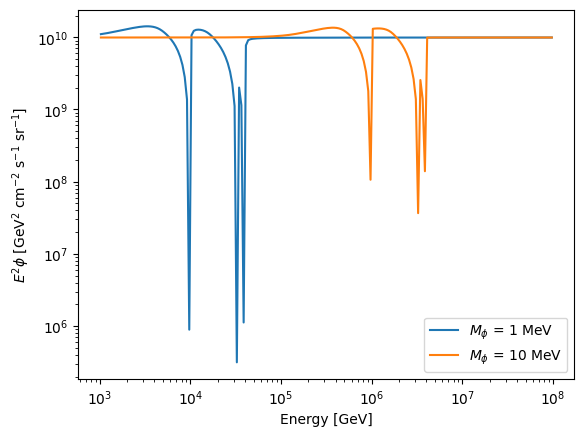

In [10]:

evolver = nuSIprop.pyprop(mphi = 1e6, # Mediator mass [eV]
            g = 0.01, # Coupling
            mntot = 0.08, # Sum of neutrino masses [eV]
            si = 2, # Spectral index
            norm = 1e-18, # Normalization of the free-streaming flux at 100 TeV [Default = 1]
            majorana = True, # Majorana neutrinos? [Default = True]
            non_resonant = True, # Include non s-channel contributions? Relevant for couplings g>~0.1 [Default = True]
            normal_ordering = True, # Normal neutrino mass ordering? [Default = True]
            N_bins_E = 200, # Number of energy bins, uniformly distributed in log space [Default = 300]
            lEmin = 12, # log_10 (E_min/eV) [Default = 13]
            lEmax = 17, # log_10 (E_max/eV) [Default = 17]
            zmax = 5, # Largest redshift at which sources are included [Default = 5]
            flav = 2, # Flavor of interacting neutrinos [0=e, 1=mu, 2=tau. Default = 2]
            phiphi = True # Consider double-scalar production? If set to true, the files xsec/alpha_phiphi.bin and xsec/alphatilde_phiphi.bin must exist [Default = False]
                        )
evolver.evolve()
energies = evolver.get_energies()

flux = evolver.get_flux_fla()
flux = flux[0] + flux[1] + flux[2]
plt.plot(energies*1e-9, flux * energies**2, label=r'$M_\phi$ = 1 MeV')
gc.collect()

evolver.set_parameters(mphi=10*1e6)
evolver.evolve()
flux = evolver.get_flux_fla()
flux = flux[0] + flux[1] + flux[2]
plt.plot(energies*1e-9, flux * energies**2, label=r'$M_\phi$ = 10 MeV')

gc.collect()



plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('$E^2 \phi$ [GeV$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.legend()
#plt.title('Best fit models')
plt.show()


In [ ]:



theta_MIO = [6.146778500918771, 0.10363516170173048, 0.10638092522721163, 2.1226924452202147, 7.747454734748619]
evolver_MIO = nuSIprop.pyprop(mphi = theta_MIO[0]*1e6, # Mediator mass [eV]
            g = theta_MIO[1], # Coupling
            mntot = theta_MIO[2], # Sum of neutrino masses [eV]
            si = theta_MIO[3], # Spectral index
            norm = theta_MIO[4] * 1e-18, # Normalization of the free-streaming flux at 100 TeV [Default = 1]
            majorana = True, # Majorana neutrinos? [Default = True]
            non_resonant = True, # Include non s-channel contributions? Relevant for couplings g>~0.1 [Default = True]
            normal_ordering = False, # Normal neutrino mass ordering? [Default = True]
            N_bins_E = 300, # Number of energy bins, uniformly distributed in log space [Default = 300]
            lEmin = 12, # log_10 (E_min/eV) [Default = 13]
            lEmax = 17, # log_10 (E_max/eV) [Default = 17]
            zmax = 5, # Largest redshift at which sources are included [Default = 5]
            flav = 2, # Flavor of interacting neutrinos [0=e, 1=mu, 2=tau. Default = 2]
            phiphi = True # Consider double-scalar production? If set to true, the files xsec/alpha_phiphi.bin and xsec/alphatilde_phiphi.bin must exist [Default = False]
                        )
evolver_MIO.evolve()
MIO_bin_avg = integrate_nuSIprop_E2phi(theta=theta_MIO)

theta_MIO = [6.146778500918771, 0.10363516170173048, 0.10638092522721163, 2.1226924452202147, 7.747454734748619]
evolver_MIO = nuSIprop.pyprop(mphi = theta_MIO[0]*1e6, # Mediator mass [eV]
            g = theta_MIO[1], # Coupling
            mntot = theta_MIO[2], # Sum of neutrino masses [eV]
            si = theta_MIO[3], # Spectral index
            norm = theta_MIO[4] * 1e-18, # Normalization of the free-streaming flux at 100 TeV [Default = 1]
            majorana = True, # Majorana neutrinos? [Default = True]
            non_resonant = True, # Include non s-channel contributions? Relevant for couplings g>~0.1 [Default = True]
            normal_ordering = False, # Normal neutrino mass ordering? [Default = True]
            N_bins_E = 300, # Number of energy bins, uniformly distributed in log space [Default = 300]
            lEmin = 12, # log_10 (E_min/eV) [Default = 13]
            lEmax = 17, # log_10 (E_max/eV) [Default = 17]
            zmax = 5, # Largest redshift at which sources are included [Default = 5]
            flav = 2, # Flavor of interacting neutrinos [0=e, 1=mu, 2=tau. Default = 2]
            phiphi = True # Consider double-scalar production? If set to true, the files xsec/alpha_phiphi.bin and xsec/alphatilde_phiphi.bin must exist [Default = False]
                        )
evolver_MIO.evolve()
MIO_bin_avg = integrate_nuSIprop_E2phi(theta=theta_MIO)

theta_DNO =  [0.44727279432446193, 0.015519735890792644, 0.059045210101645366, 2.6115632949445837, 10.20198720559154]
evolver_DNO = nuSIprop.pyprop(mphi = theta_DNO[0]*1e6, # Mediator mass [eV]
            g = theta_DNO[1], # Coupling
            mntot = theta_DNO[2], # Sum of neutrino masses [eV]
            si = theta_DNO[3], # Spectral index
            norm = theta_DNO[4] * 1e-18, # Normalization of the free-streaming flux at 100 TeV [Default = 1]
            majorana = False, # Majorana neutrinos? [Default = True]
            non_resonant = True, # Include non s-channel contributions? Relevant for couplings g>~0.1 [Default = True]
            normal_ordering = True, # Normal neutrino mass ordering? [Default = True]
            N_bins_E = 300, # Number of energy bins, uniformly distributed in log space [Default = 300]
            lEmin = 12, # log_10 (E_min/eV) [Default = 13]
            lEmax = 17, # log_10 (E_max/eV) [Default = 17]
            zmax = 5, # Largest redshift at which sources are included [Default = 5]
            flav = 2, # Flavor of interacting neutrinos [0=e, 1=mu, 2=tau. Default = 2]
            phiphi = True # Consider double-scalar production? If set to true, the files xsec/alpha_phiphi.bin and xsec/alphatilde_phiphi.bin must exist [Default = False]
                        )
evolver_DNO.evolve()
DNO_bin_avg = integrate_nuSIprop_E2phi(theta=theta_DNO)

theta_DIO =  [0.8666222255525288, 0.027758096433915552, 0.10010012813679053, 2.589493436530274, 14.374786484680799]
evolver_DIO = nuSIprop.pyprop(mphi = theta_DIO[0]*1e6, # Mediator mass [eV]
            g = theta_DIO[1], # Coupling
            mntot = theta_DIO[2], # Sum of neutrino masses [eV]
            si = theta_DIO[3], # Spectral index
            norm = theta_DIO[4] * 1e-18, # Normalization of the free-streaming flux at 100 TeV [Default = 1]
            majorana = False, # Majorana neutrinos? [Default = True]
            non_resonant = True, # Include non s-channel contributions? Relevant for couplings g>~0.1 [Default = True]
            normal_ordering = False, # Normal neutrino mass ordering? [Default = True]
            N_bins_E = 300, # Number of energy bins, uniformly distributed in log space [Default = 300]
            lEmin = 12, # log_10 (E_min/eV) [Default = 13]
            lEmax = 17, # log_10 (E_max/eV) [Default = 17]
            zmax = 5, # Largest redshift at which sources are included [Default = 5]
            flav = 2, # Flavor of interacting neutrinos [0=e, 1=mu, 2=tau. Default = 2]
            phiphi = True # Consider double-scalar production? If set to true, the files xsec/alpha_phiphi.bin and xsec/alphatilde_phiphi.bin must exist [Default = False]
                        )
evolver_DIO.evolve()
DIO_bin_avg = integrate_nuSIprop_E2phi(theta=theta_DIO)

: 

In [ ]:
plt.sca
plt.errorbar(energy_centers_MESE, y_obs, 
             yerr=[sigma_lower, sigma_upper], 
             fmt='x', color='grey', label='Events', capsize=3, markersize=6, linestyle='none', alpha=0.9)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('$E^2 \phi$ [GeV$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.legend()
plt.title('Best fit models')
plt.show()

In [75]:

#theta = [20, 0.01, 0.07, 2.548, 2*2.13*1e-18]
#theta = [39.03059910524562, 0.00042970221381601336, 0.114384446591275, 2.6855511867911517, 1.3544599291118502e-18]
#theta = [7.915010269044294, 0.0011067838169519161, 0.0626165943321897, 3.0311637298813476, 2.550226573682637e-09]
#theta = [12.51097031040926, 0.014107459327646643, 0.1385678945551038, 3.5915912797202445, 6.519071442950406e-10]
#theta = [34.62904650575734, 0.24812191654151713, 0.09347253611024776, 2.3095098825940363, 6.952525597298649e-18]
"""
nuSIprop_flx_bin_averaged = nuSIprop_flux_binavg_trap(theta)
print('nuSIprop_flx_bin_averaged: ', nuSIprop_flx_bin_averaged)

y_err = sigma1 + sigma2 * (nuSIprop_flx_bin_averaged - y_obs)
print('y_err: ', y_err)
print('log likelihood: ', -0.5 * (y_obs - nuSIprop_flx_bin_averaged)**2 / y_err**2 - np.log(y_err))
print('total log likelihood: ', -0.5 * np.sum((y_obs - nuSIprop_flx_bin_averaged)**2 / y_err**2))

"""
#print(perflavor)

spl_flux = SPL_flux(energies=energy_centers_MESE, si=2.548, norm=2.13*1e-18)
#lp_flux = LP_flux(energies=energy_centers_MESE, alpha=3.164431771688147, beta=0.999686262464528, norm=2.4854813536011315*1e-18)
bpl_flux = BPL_flux(energies=energy_centers_MESE, si1=1.72, si2=2.839, E_break=10**4.524, norm=2.28*1e-18)
lp_flux = LP_flux(energies=energy_centers_MESE, alpha=2.668, beta=0.359, norm=2.58*1e-18)


#print('total log likelihood_spl: ', -0.5 * np.sum((y_obs - spl_flux)**2 / y_err_spl**2) - np.sum(np.log(y_err_spl)))
#print('total log likelihood_lp: ', -0.5 * np.sum((y_obs - lp_flux)**2 / y_err_lp**2) - np.sum(np.log(y_err_lp)))
#theta_LP = [2.4854813536011315*1e-18, 3.164431771688147, 0.999686262464528]
#theta_LP = [2.4854813536011315*1e-18, 3.164431771688147, 0.999686262464528]
#log_like_LP = loglike_LP(theta_LP)

BPL_bin_avg = integrate_model_E2phi(theta=[2.28*1e-18, 1.72, 2.839, 10**4.524], bin_edges=energy_edges_MESE)
LP_bin_avg = integrate_model_E2phi(theta=[2.58*1e-18, 2.668, 0.359], bin_edges=energy_edges_MESE)

y_err_bpl = sigma1 + sigma2 * (BPL_bin_avg - y_obs)
y_err_lp = sigma1 + sigma2 * (LP_bin_avg - y_obs)

print('log likelihood_bpl: ', -0.5 * (y_obs - BPL_bin_avg)**2 / y_err_bpl**2)
print('total log likelihood_bpl: ', -0.5 * np.sum((y_obs - BPL_bin_avg)**2 / y_err_bpl**2))
print('log likelihood_lp: ', -0.5 * (y_obs - LP_bin_avg)**2 / y_err_lp**2)
print('total log likelihood_lp: ', -0.5 * np.sum((y_obs - LP_bin_avg)**2 / y_err_lp**2))

theta = [1, 0.05, 0.01, 2.4, 7]
nuSIprop_flx = integrate_nuSIprop_E2phi(theta, interaction=True)
print('nuSIprop_flx: ', nuSIprop_flx)
log_like_nuSIprop = loglike_nuSIprop(theta)

print('log likelihood_nuSIprop: ', log_like_nuSIprop)
evolver.set_parameters(mphi=theta[0]*1e6, g=theta[1], mntot=theta[2], si=theta[3], norm=theta[4]*1e-18)
evolver.evolve()
flux = evolver.get_flux_fla()
E = evolver.get_energies() / 1e9
perflavor = (flux[0,:] + flux[1,:] + flux[2,:]) / 3.0


#plt.plot(energy_centers_MESE, spl_flux * energy_centers_MESE**2, label='SPL, raw', alpha=0.5, color='blue')
#plt.plot(energy_centers_MESE, lp_flux * energy_centers_MESE**2, label='LP, raw')
plt.scatter(energy_centers_MESE, BPL_bin_avg, label='BPL, bin averaged', alpha=0.5, color='blue')
plt.scatter(energy_centers_MESE, LP_bin_avg, label='LP, bin averaged', alpha=0.5, color='green')

plt.plot(E, perflavor * E**2, label='nuSIprop, raw', linestyle='--', color='red')
plt.scatter(energy_centers_MESE, nuSIprop_flx, label='nuSIprop, bin averaged', color='red')
plt.errorbar(energy_centers_MESE, y_obs, 
             yerr=[sigma_lower, sigma_upper], 
             fmt='x', color='black', label='Events', capsize=3, markersize=5, linestyle='none')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('$E^2 \phi$ [GeV$^2$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.legend()
plt.show()




: 

In [44]:

from scipy.stats import norm

def loglike_asym_censored(y_obs, y_pred, is_upper):
    """
    Compute log-likelihood for data with asymmetric errors and upper limits.
    
    Parameters
    ----------
    y_obs : array-like
        Observed central values (for upper limits, can be 0.0 or np.nan).
    y_pred : array-like
        Predicted values from the model (same length as y_obs).
    sigma_minus : array-like
        Lower-side errors for each bin (0 if no lower error reported).
    sigma_plus : array-like
        Upper-side errors for each bin.
    is_upper : boolean array
        True if bin is an upper limit (only upper boundary reported).
    """
    y_obs   = np.asarray(y_obs)
    y_pred  = np.asarray(y_pred)
    #sigma_m = np.asarray(sigma_minus)
    #sigma_p = np.asarray(sigma_plus)
    is_upper = np.asarray(is_upper)

    logL = np.zeros_like(y_pred, dtype=float)

    # --- Upper limits: log CDF ---
    if np.any(is_upper):
        idx = np.nonzero(is_upper)[0]
        L = sigma_upper[idx]  # treat reported "+σ" as the limit value
        # choose σ from sigma_plus (uncertainty in upward fluctuations)
        sigma_tail = sigma_upper[idx]
        z = (L - y_pred[idx]) / sigma_tail
        logL[idx] = norm.logcdf(z)

    # --- Measured bins: split-normal ---
    if np.any(~is_upper):
        idx = np.nonzero(~is_upper)[0]
        y_o = y_obs[idx]
        y_p = y_pred[idx]
        res = y_p - y_o

        # pick σ depending on side
        sigma = np.where(res < 0, sigma_lower[idx], sigma_upper[idx])

        # normalization term (independent of y_pred)
        norm_term = np.log(sigma_lower[idx] + sigma_upper[idx])
        print('norm_term: ', norm_term)

        chi2_term = -0.5 * (res / sigma)**2
        print('chi2_term: ', chi2_term)
        logL[idx] = chi2_term - norm_term
    print('logL: ', logL)

    return np.sum(logL)


def split_normal_loglike(y_obs, y_pred, sigma_lower, sigma_upper, is_upper):
    y_obs   = np.asarray(y_obs)
    y_pred  = np.asarray(y_pred)
    is_upper = np.asarray(is_upper)

    logL = np.zeros_like(y_pred, dtype=float)
    norm = np.sqrt(2 /np.pi) / (sigma_lower + sigma_upper)
    
    for i in range(len(y_pred)):
        if y_pred[i] > y_obs[i]:
            logL[i] = -(y_pred[i] - y_obs[i])**2 / (2 * sigma_upper[i]**2) + np.log(norm[i])
        else:
            logL[i] = -(y_pred[i] - y_obs[i])**2 / (2 * sigma_lower[i]**2) + np.log(norm[i])
            
    return np.sum(logL)
    



# Mark upper-limit bins
is_upper = np.zeros_like(norm_segmented, dtype=bool)
print(is_upper)
is_upper[[0, 10, 12]] = True
print(is_upper)
# Example: evaluate log-likelihood for some model prediction
#y_pred_example = np.linspace(0, 6, len(norm_segmented))
y_pred_example = LP_bin_avg
print('y_pred_example: ', y_pred_example)
print('y_obs: ', y_obs)
logL_val = loglike_asym_censored(norm_segmented, y_pred_example, is_upper)

logL_split = split_normal_loglike(y_obs, y_pred_example, sigma_lower, sigma_upper, is_upper)

print("Total log-likelihood:", logL_val)
print("Total log-likelihood:", logL_split)


[False False False False False False False False False False False False
 False]
[ True False False False False False False False False False  True False
  True]
y_pred_example:  [3.29450280e-07 2.88078656e-07 2.16404289e-07 1.39835133e-07
 7.75954250e-08 3.69728123e-08 1.51506364e-08 5.33494783e-09
 1.61429488e-09 4.19855959e-10 9.38304996e-11 1.80192022e-11
 5.28577394e-13]
y_obs:  [0.00e+00 5.40e-08 3.90e-08 4.41e-08 5.51e-08 3.34e-08 1.55e-08 3.10e-09
 5.90e-09 3.27e-09 0.00e+00 2.50e-09 0.00e+00]
norm_term:  [-16.00476697 -17.00969377 -17.81636478 -18.09859724 -18.2809188
 -18.58319967 -18.86696785 -18.85146366 -19.0940253  -19.33697148]
chi2_term:  [-4.99999947e+15 -1.90124979e+16 -1.20049992e+17 -3.48485987e+17
 -2.06279581e+17 -9.80612226e+16 -4.99999983e+15 -3.29017011e+16
 -1.48101108e+16 -1.22070312e+16]
logL:  [-1.68600296e+01 -4.99999947e+15 -1.90124979e+16 -1.20049992e+17
 -3.48485987e+17 -2.06279581e+17 -9.80612226e+16 -4.99999983e+15
 -3.29017011e+16 -1.48101108e+16 -1.

In [1]:
# Old log-likelihood 
# beta=0.999686262464528
259.90095829579474
# beta=0.3
171.73448884583647

# New log-likelihood 
# beta=0.999686262464528
228.3864017476985
# beta=0.3
108.33382908865292



energy_centers_high_resolution = np.logspace(np.log10(energy_centers_MESE[0]), np.log10(energy_centers_MESE[-1]), 100)

y_pred_SPL_raw = SPL_flux(energies=energy_centers_high_resolution) * energy_centers_high_resolution**2
y_pred_BPL_raw = BPL_flux(energies=energy_centers_high_resolution) * energy_centers_high_resolution**2
y_pred_LP_raw = LP_flux(energies=energy_centers_high_resolution) * energy_centers_high_resolution**2

lower_index = 2
upper_index = -1

print('energy centers withing sensitivity range: ', energy_centers_MESE)
print('energy edges: ', energy_edges_MESE)
print('sigma1: ', sigma1)
print('sigma2: ', sigma2)

y_pred_SPL_bin_avg = model_predict_E2phi_per_bin(SPL_flux, energy_edges_MESE)
y_pred_BPL_bin_avg = model_predict_E2phi_per_bin(BPL_flux, energy_edges_MESE)
y_pred_LP_bin_avg = model_predict_E2phi_per_bin(LP_flux, energy_edges_MESE)

y_err_SPL = sigma1 + sigma2 * (y_pred_SPL_bin_avg - y_obs)
y_err_BPL = sigma1 + sigma2 * (y_pred_BPL_bin_avg - y_obs)
y_err_LP = sigma1 + sigma2 * (y_pred_LP_bin_avg - y_obs)
print('SPL error: ', y_err_SPL)
print('BPL error: ', y_err_BPL)
print('LP error: ', y_err_LP)

ll_SPL = -0.5 * (y_obs - y_pred_SPL_bin_avg)**2 / y_err_SPL**2 - np.log(y_err_SPL)
ll_BPL = -0.5 * (y_obs - y_pred_BPL_bin_avg)**2 / y_err_BPL**2 - np.log(y_err_BPL)
ll_LP = -0.5 * (y_obs - y_pred_LP_bin_avg)**2 / y_err_LP**2 - np.log(y_err_LP)
#ll_LP[-4] = 0

print('Log likelihoods for integrated bin averages: ', ll_SPL, ll_BPL, ll_LP)
print('Total log likelihoods: ', np.sum(ll_SPL), np.sum(ll_BPL), np.sum(ll_LP))
TS_BPL = 2 * (np.sum(ll_SPL) - np.sum(ll_BPL))
TS_LP = 2 * (np.sum(ll_SPL) - np.sum(ll_LP))
print('TS: ', TS_BPL, TS_LP)


plt.scatter(energy_centers_high_resolution, 1e-18*y_pred_SPL_raw, label='SPL, raw', alpha=0.5)
plt.scatter(energy_centers_high_resolution, 1e-18*y_pred_BPL_raw, label='BPL, raw', alpha=0.5)
plt.scatter(energy_centers_high_resolution, 1e-18*y_pred_LP_raw, label='LP, raw', alpha=0.5)
plt.scatter(energy_centers_MESE, 1e-18*y_obs, label='MESE data', alpha=0.5, marker='x')
plt.scatter(energy_centers_MESE, 1e-18*y_pred_SPL_bin_avg, label='SPL, bin averaged', alpha=0.5)
plt.scatter(energy_centers_MESE, 1e-18*y_pred_BPL_bin_avg, label='BPL, bin averaged', alpha=0.5)
plt.scatter(energy_centers_MESE, 1e-18*y_pred_LP_bin_avg, label='LP, bin averaged', alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('E$^2 \phi$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.legend()
plt.show()

NameError: name 'np' is not defined

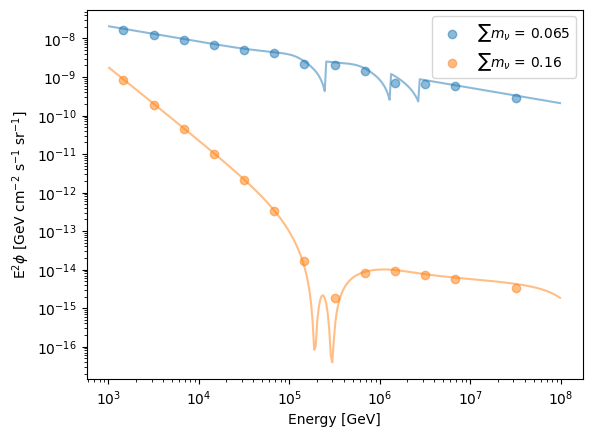

In [24]:
def integrate_nuSIprop_E2phi(theta):
    #Mphi, g, si = theta
    Mphi, g, mntot, si, norm = theta
    evolver.set_parameters(mphi=Mphi*1e6, g=g, mntot=mntot, si=si)
    evolver.evolve()
    flux = evolver.get_flux_fla()                      # shape (nE, flavors)
    E_samples = evolver.get_energies() / 1e9           # ensure same units as energy_edges_MESE (GeV)
    perflavor = (flux[0,:] + flux[1,:] + flux[2,:]) / 3.0  # or flux.T/columns depending on shape

    preds = []
    for Emin, Emax in zip(energy_edges_MESE[:-1], energy_edges_MESE[1:]):
        # select indices inside the bin (include endpoints carefully)
        mask = (E_samples >= Emin) & (E_samples <= Emax)
        Es = E_samples[mask]
        phis = perflavor[mask]

        if Es.size == 0:
            # fallback: interpolate phi on a fine grid and integrate, or use nearest neighbor
            preds.append(0.0)
            continue

        # integrate E^2 * phi(E) over the bin using trapezoid rule
        integrand = (Es**2) * phis
        integral = np.trapz(integrand, Es)   # approximates ∫ E^2 phi dE
        preds.append(integral / (Emax - Emin))   # bin-averaged E^2 phi

    return np.array(preds), E_samples, perflavor


average_1, E_samples_1, perflavor_1 = integrate_nuSIprop_E2phi(theta=[5, 0.001, 0.065, 2.4, 1])
average_2, E_samples_2, perflavor_2 = integrate_nuSIprop_E2phi(theta=[5, 1, 0.15, 2.9, 7])

#print('nuSIprop_1: ', nuSIprop_1)
#print('nuSIprop_2: ', nuSIprop_2)

plt.scatter(energy_centers_MESE, average_1, label=r'$\sum m_{\nu}$ = 0.065', alpha=0.5)
plt.scatter(energy_centers_MESE, average_2, label=r'$\sum m_{\nu}$ = 0.16', alpha=0.5)
plt.plot(E_samples_1, perflavor_1 * E_samples_1**2, alpha=0.5)
plt.plot(E_samples_2, perflavor_2 * E_samples_2**2, alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy [GeV]')
plt.ylabel('E$^2 \phi$ [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
plt.legend()
plt.show()


In [22]:
def integrate_nuSIprop_E2phi(theta, interaction=True):
    #Mphi, g, si = theta
    #Mphi, g, mntot, si, norm = theta
    if interaction:
        Mphi, g, si, norm, mntot = theta
        evolver.set_parameters(mphi=Mphi*1e6, g=g, si=si, norm=norm*1e-18, mntot=mntot)
    else:
        si, norm = theta
        evolver.set_parameters(si=si, norm=norm*1e-18)
    #evolver.set_parameters(mphi=Mphi*1e6, g=g, mntot=mntot, si=si, norm=norm)
    
    evolver.evolve()
    flux = evolver.get_flux_fla()                      # shape (nE, flavors)
    E_samples = evolver.get_energies() / 1e9           # ensure same units as energy_edges_MESE (GeV)
    perflavor = (flux[0,:] + flux[1,:] + flux[2,:]) / 3.0  # or flux.T/columns depending on shape

    preds = []
    for Emin, Emax in zip(energy_edges_MESE[:-1], energy_edges_MESE[1:]):
        # select indices inside the bin (include endpoints carefully)
        mask = (E_samples >= Emin) & (E_samples <= Emax)
        Es = E_samples[mask]
        phis = perflavor[mask]

        if Es.size == 0:
            # fallback: interpolate phi on a fine grid and integrate, or use nearest neighbor
            preds.append(0.0)
            continue

        # integrate E^2 * phi(E) over the bin using trapezoid rule
        integrand = (Es**2) * phis
        print('integrand: ', integrand)
        integral = np.trapz(integrand, Es)   # approximates ∫ E^2 phi dE
        preds.append(integral / (Emax - Emin))   # bin-averaged E^2 phi

    return np.array(preds)

print(integrate_nuSIprop_E2phi(theta=[5, 0.001, 2.4, 1, 0.20], interaction=True))

integrand:  [2.06908040e-08 2.03756759e-08 2.00653531e-08 1.97597629e-08
 1.94588337e-08 1.91624948e-08 1.88706769e-08 1.85833116e-08
 1.83003317e-08 1.80216710e-08 1.77472644e-08 1.74770478e-08
 1.72109582e-08 1.69489335e-08 1.66909127e-08 1.64368359e-08
 1.61866440e-08 1.59402790e-08 1.56976839e-08 1.54588026e-08]
integrand:  [1.52235799e-08 1.49919618e-08 1.47638949e-08 1.45393270e-08
 1.43182069e-08 1.41004840e-08 1.38861091e-08 1.36750335e-08
 1.34672096e-08 1.32625910e-08 1.30611318e-08 1.28627873e-08
 1.26675138e-08 1.24752684e-08 1.22860092e-08 1.20996954e-08
 1.19162870e-08 1.17357452e-08 1.15580320e-08 1.13831108e-08]
integrand:  [1.12109455e-08 1.10415017e-08 1.08747457e-08 1.07106451e-08
 1.05491685e-08 1.03902860e-08 1.02339688e-08 1.00801892e-08
 9.92892124e-09 9.78014001e-09 9.63382223e-09 9.48994607e-09
 9.34849132e-09 9.20943941e-09 9.07277352e-09 8.93847868e-09
 8.80654182e-09 8.67695195e-09 8.54970019e-09 8.42477997e-09]
integrand:  [8.30218714e-09 8.18192010e-09 8.0

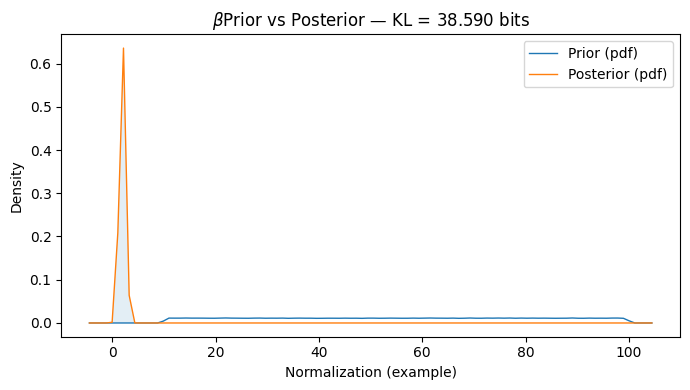

Estimated information gain (KL) = 38.5904 bits for example 1.


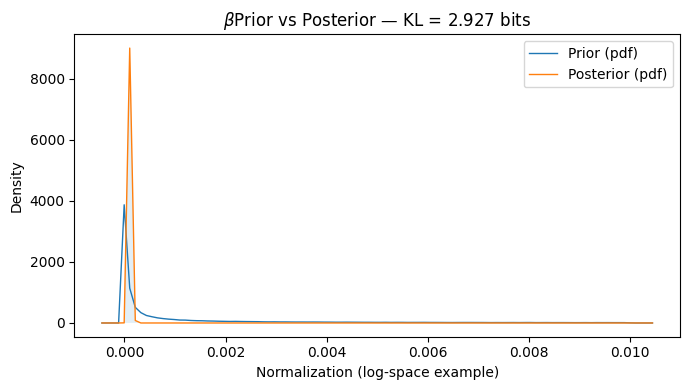

Estimated information gain (KL) = 2.9272 bits for example 2.


(38.59042234310777, 2.927167723951752)

In [16]:
# plotting prior vs posterior example and computing information gain (KL in bits)

from scipy.stats import entropy, norm
import math

def compute_kl_bits(prior_samples, posterior_samples, nbins=200, range_pad=0.05):
    """
    Estimate KL(posterior || prior) in bits using histogram discretization.
    Returns KL in bits, and the bin edges and histograms (pdf estimates).
    """
    # Build a range that covers both
    amin = min(prior_samples.min(), posterior_samples.min())
    amax = max(prior_samples.max(), posterior_samples.max())
    rng = amax - amin
    amin -= rng * range_pad
    amax += rng * range_pad

    bins = np.linspace(amin, amax, nbins+1)
    p_prior, _ = np.histogram(prior_samples, bins=bins, density=True)
    p_post, _  = np.histogram(posterior_samples, bins=bins, density=True)

    # small floor to avoid zero probabilities (necessary for stable KL)
    eps = 1e-12
    p_prior = np.maximum(p_prior, eps)
    p_post  = np.maximum(p_post, eps)

    # KL in nats: sum p_post * log(p_post / p_prior) * bin_width
    bin_widths = np.diff(bins)
    kl_nats = np.sum(p_post * np.log(p_post / p_prior) * bin_widths)
    kl_bits = kl_nats / np.log(2.0)
    return kl_bits, bins, p_prior, p_post

def plot_prior_posterior(prior_samples, posterior_samples, param_name="param", nbins=100):
    kl_bits, bins, p_prior, p_post = compute_kl_bits(prior_samples, posterior_samples, nbins=nbins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    plt.figure(figsize=(7,4))
    plt.plot(bin_centers, p_prior, label="Prior (pdf)", linewidth=1)
    plt.plot(bin_centers, p_post,  label="Posterior (pdf)", linewidth=1)
    plt.fill_between(bin_centers, p_post, alpha=0.12)
    plt.xlabel(param_name)
    plt.ylabel("Density")
    plt.title(r"$\beta$" +f"Prior vs Posterior — KL = {kl_bits:.3f} bits")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return kl_bits

# -----------------------
# Example 1: Uniform prior on [0,10], posterior ~ Normal(2, 0.5)
np.random.seed(1)
prior_uniform = np.random.uniform(10, 100, size=200000)
posterior_synth = np.random.normal(loc=2.0, scale=0.5, size=20000)

kl_bits_example = plot_prior_posterior(prior_uniform, posterior_synth, param_name="Normalization (example)")
print(f"Estimated information gain (KL) = {kl_bits_example:.4f} bits for example 1.")

# -----------------------
# Example 2: Log-uniform prior on [1e-6, 1e-2], posterior peaked near 1e-4
prior_log = 10**(np.random.uniform(np.log10(1e-6), np.log10(1e-2), size=200000))
# posterior samples (log-normal-like)
posterior_log = np.exp(np.random.normal(np.log(1e-4), 0.2, size=20000))

kl_bits_example2 = plot_prior_posterior(prior_log, posterior_log, param_name="Normalization (log-space example)")
print(f"Estimated information gain (KL) = {kl_bits_example2:.4f} bits for example 2.")

# Return the functions in case the user wants to reuse them interactively
kl_bits_example, kl_bits_example2



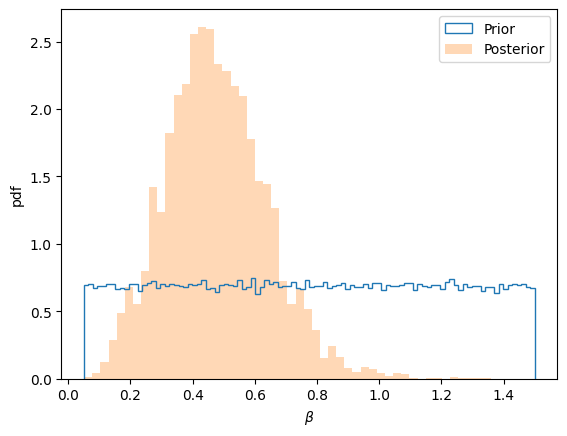

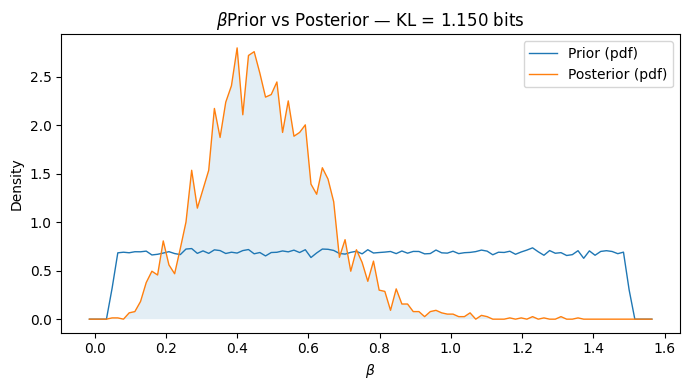

1.1500305794327912

In [17]:

# Load posterior samples

post = np.loadtxt("./cluster/ultranest/mese/run3_LP/chains/equal_weighted_post.txt", skiprows=1)
norm_post = post[:,2]  # first column = norm

# Generate synthetic prior samples (example: log-uniform in [1e-20, 1e-15])
prior_norm = np.random.uniform(0.05, 1.5, size=100000)

# Plot
plt.hist(prior_norm, bins=100, density=True, histtype='step', label="Prior")
plt.hist(norm_post, bins=50, density=True, histtype='stepfilled', alpha=0.3, label="Posterior")
plt.xlabel(r"$\beta$")
plt.ylabel("pdf")
plt.legend()
plt.show()

plot_prior_posterior(prior_norm, norm_post, param_name=r"$\beta$")
